# **Analisis Deskriptif dan Inferensial Kesenjangan Aktivitas Review pada Listing Airbnb Berdasarkan Lokasi, Harga, dan Tipe Properti**

## **Latar Belakang**
Airbnb adalah perusahan pihak ketiga yang menghubungkan host (pemilik properti) dengan tamu yang mencari penginapan jangka panjang maupun pendek. Airbnb telah berdiri sejak 2008 dan mengalami pertumbuhan pesat di tahun 2012. Selama itu juga, Airbnb memfasilitasi platform bagi para host untuk menyewakan berbagai properti penginapan: kamar pribadi, apartemen, villa, maupun keseluruhan rumah. Airbnb merupakan salah satu pelopor jaringan pasar daring untuk industri akomodasi. Platform Airbnb memudahkan pendaftaran listing bagi host serta penyewaan properti bagi tamu secara daring.

## **Masalah Bisnis**
Bisnis yang ditawarkan secara digital saat ini sangat mengandalkan review dari customer, tidak terkecuali industri akomodasi. Properti sewaan dengan review yang sedikit atau bahkan tidak ada, cenderung kurang meninggalkan kesan baik bagi tamu. Pada dataset Airbnb Listings Bangkok, ditemukan banyaknya listing dengan review 0. Dari sudut pandang tamu, listing akan tampak kurang menarik untuk dipilih. Analisis ini akan berfokus pada kesenjangan aktivitas review listing, apakah karakteristik listing memiliki pengaruh terhadap aktivitas review listing, serta seberapa signifikan karakteristik tersebuh berpengaruh terhadap aktivitas review listing. 


#### Pertanyaan Masalah
1. Bagaimana distribusi aktivitas review (`number_of_reviews`) pada listing Airbnb di Bangkok berdasarkan lokasi (`neighbourhood`), harga (`price`), dan tipe properti (`room_type`)?
2. Apakah terdapat perbedaan signifikan dalam jumlah review antara:
    - Listing di berbagai wilayah (`neighbourhood`)?
    - Listing dengan harga yang berbeda?
    - Listing dengan tipe properti yang berbeda?


#### Tujuan
1. Mendeskripsikan distribusi jumlah review berdasarkan lokasi, harga, dan tipe properti.
2. Menguji signifikansi perbedaan jumlah review antara:
    - Listing di berbagai wilayah (`neighbourhood`)?
    - Listing dengan harga yang berbeda?
    - Listing dengan tipe properti yang berbeda?



## **Overview**
Analisis menunjukkan bahwa aktivitas review listing Airbnb di Bangkok masih timpang, dengan proporsi listing tanpa review yang cukup besar, terutama pada tipe **Private Room** dan wilayah seperti Vadhana, Khlong Toei, dan Huai Khwang. Tipe properti terbukti menjadi faktor paling berpengaruh terhadap jumlah review, disusul oleh lokasi, sementara harga hampir tidak berdampak signifikan. Namun, temuan ini dibatasi oleh rentang data 2012–2022 serta tidak mempertimbangkan faktor kualitas properti, performa host, maupun sentimen review. Untuk meningkatkan engagement, disarankan strategi terpadu berupa peningkatan kualitas listing dan layanan host, program insentif dan loyalitas bagi tamu, promosi yang lebih terarah (termasuk kolaborasi influencer), serta dukungan berbasis data seperti dashboard performa dan intervensi khusus bagi listing dengan review rendah.









In [767]:
# import modul-modul yang diperlukan

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

import folium
import geocoder
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from folium.plugins import MarkerCluster, HeatMap

from scipy import stats
from scipy.stats import shapiro
from scipy.stats import kruskal

pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows',None)

## **1. Import/Read Data**

In [768]:
airbnb = pd.read_csv('Airbnb Listings Bangkok.csv', parse_dates=['last_review'])
airbnb.drop('Unnamed: 0', axis=1, inplace=True)
airbnb

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.759830,100.541340,Entire home/apt,1905,3,65,2020-01-06,0.50,2,353,0
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.668180,100.616740,Private room,1316,1,0,NaT,NaN,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.752320,100.624020,Private room,800,60,0,NaT,NaN,1,365,0
3,35780,Spacious one bedroom at The Kris Condo Bldg. 3,153730,Sirilak,Din Daeng,13.788230,100.572560,Private room,1286,7,2,2022-04-01,0.03,1,323,1
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.768720,100.633380,Private room,1905,1,0,NaT,NaN,3,365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,NaN,1,362,0
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,NaN,14,365,0
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,NaN,14,365,0
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,NaN,14,365,0


## **2. Data Understanding**
### Column Descriptions:
Dataset Airbnb Listings Bangkok berisi informasi mengenai berbagai listing penginapan, di mana setiap baris data merepresentasikan satu listing yang disewakan oleh para host di kota Bangkok. Agar lebih mengenal dataset ini, kolom-kolom pada dataset akan didefinisikan dan dikategorikan sebagai berikut:

1. Identifikasi:
    - `id`                              : Identitas unik setiap listing
    - `name`                            : Merujuk pada nama listing
    - `host_id`                         : Identitas unik setiap host
    - `host_name`                       : Merujuk pada nama host
    - `calculated_host_listings_count`  : Total listing yang dimiliki host di wilayah tertentu

2. Informasi Lokasi Listing:
    - `neighbourhood`   : Nama wilayah/lingkungan tempat listing berada
    - `latitude`        : Koordinat lintang lokasi listing
    - `longitude`       : Koordinat bujur lokasi listing

3. Karakteristik Listing:
    - `room_type`               : Tipe listing yang dibagi menjadi empat: Entire home/apt, Private room, Hotel room, Shared room
    - `price`                   : Harga sewa listing per malam
    - `minimum_nights`          : Batas minimal malam menginap
    - `number_of_reviews`       : Banyaknya review untuk listing oleh tamu
    - `last_review`             : Tanggal terakhir listing diberi review oleh tamu
    - `reviews_per_month`       : Rata-rata jumlah review per bulan
    - `availability_365`        : Jumlah hari listing tersedia untuk dipesan dalam satu tahun
    - `number_of_reviews_ltm`   : Banyaknya review dalam dua belas bulan terakhir


In [769]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              15854 non-null  int64         
 1   name                            15846 non-null  object        
 2   host_id                         15854 non-null  int64         
 3   host_name                       15853 non-null  object        
 4   neighbourhood                   15854 non-null  object        
 5   latitude                        15854 non-null  float64       
 6   longitude                       15854 non-null  float64       
 7   room_type                       15854 non-null  object        
 8   price                           15854 non-null  int64         
 9   minimum_nights                  15854 non-null  int64         
 10  number_of_reviews               15854 non-null  int64         
 11  la

Dari informasi di atas, dapat kita amati tipe data dari masing-masing kolom. Untuk kolom `id` dan `host_id` perlu kita casting menjadi string agar dataset lebih konsisten saat mengecek deskripsi dari dataset. 

In [770]:
airbnb['id']=airbnb['id'].astype(str)
airbnb['host_id']=airbnb['host_id'].astype(str)


In [771]:
airbnb[['id','host_id']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15854 entries, 0 to 15853
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       15854 non-null  object
 1   host_id  15854 non-null  object
dtypes: object(2)
memory usage: 247.8+ KB


Tipe data kolom `id` dan `host_id` telah berhasil diubah. Selanjutnya masuk ke tahap data pre-processing dan data cleaning

## 3. Data Pre-Processing/Data Cleaning

### 1. Missing Value
Pada raw data Airbnb Listings Bangkok, pertama-tama kita perlu mengecek missing value dari setiap kolom.

In [772]:
check_missing = pd.DataFrame(round(airbnb.isna().sum()*100/len(airbnb),1)).reset_index()
check_missing.rename(columns={'index':'column', 0:'missing percentage'},inplace=True)
check_missing['missing percentage'] = (check_missing['missing percentage'].astype(str)+'%')
check_missing

,column,missing percentage
0,id,0.0%
1,name,0.1%
2,host_id,0.0%
3,host_name,0.0%
4,neighbourhood,0.0%
5,latitude,0.0%
6,longitude,0.0%
7,room_type,0.0%
8,price,0.0%
9,minimum_nights,0.0%


Visualisasi nilai hilang dapat kita lihat pada grafik berikut:

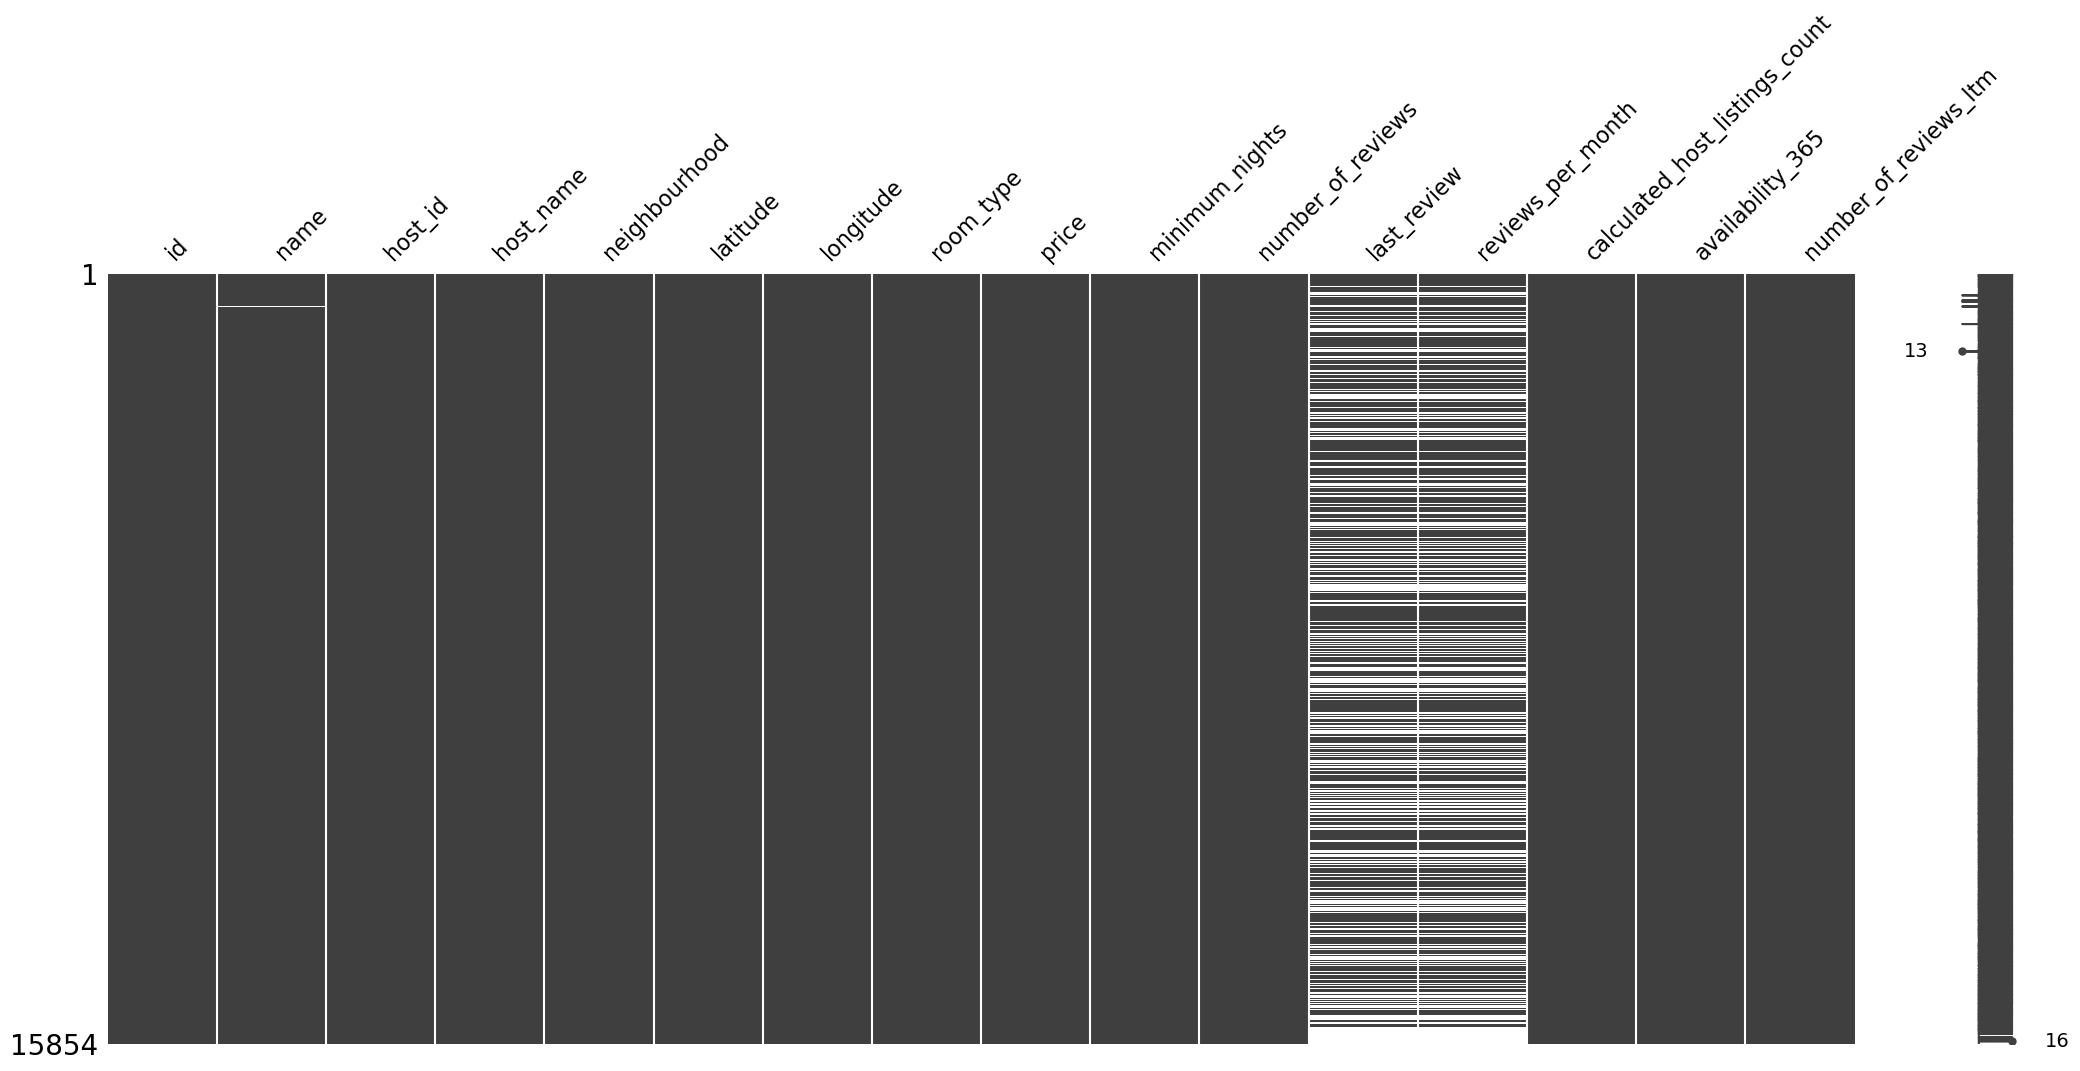

In [773]:
msno.matrix(airbnb)
plt.show()

Persentase nilai yang hilang paling banyak ada di kolom `last_review` dan `reviews_per_month` serta sebagian kecil di kolom `name`. Untuk menangani nilai hilang ini, perlu dicek ulang apakah nilai-nilai tersebut berkaitan dengan kolom lain.

In [774]:
airbnb[['last_review', 'reviews_per_month']].isna().sum()


last_review          5790
reviews_per_month    5790
dtype: int64

In [775]:
zero_review = airbnb[
    airbnb['number_of_reviews']==0
]
zero_review

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.668180,100.616740,Private room,1316,1,0,NaT,NaN,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.752320,100.624020,Private room,800,60,0,NaT,NaN,1,365,0
4,941865,Suite Room 3 at MetroPoint,610315,Kasem,Bang Kapi,13.768720,100.633380,Private room,1905,1,0,NaT,NaN,3,365,0
7,1738669,1 chic bedroom apartment in BKK,7045870,Jiraporn,Chatu Chak,13.829250,100.567370,Entire home/apt,1461,1,0,NaT,NaN,1,365,0
14,959254,"Deluxe Condo, Nana, Pool/GYM/Sauna",5153476,Natcha,Khlong Toei,13.715160,100.568060,Entire home/apt,1400,30,0,NaT,NaN,1,365,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15849,790465040741092826,素坤逸核心两房公寓42楼，靠近BTSon nut/无边天际泳池观赏曼谷夜景/出门当地美食街,94899359,Renee,Pra Wet,13.715132,100.653458,Private room,2298,28,0,NaT,NaN,1,362,0
15850,790474503157243541,Euro LuxuryHotel PratunamMKt TripleBdNrShoping...,491526222,Phakhamon,Ratchathewi,13.753052,100.538738,Private room,1429,1,0,NaT,NaN,14,365,0
15851,790475335086864240,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.753169,100.538700,Private room,1214,1,0,NaT,NaN,14,365,0
15852,790475546213717328,Euro LuxuryHotel PratunamMKt TwinBedNrShopingArea,491526222,Phakhamon,Ratchathewi,13.754789,100.538757,Private room,1214,1,0,NaT,NaN,14,365,0


In [776]:
zero_review[['last_review','reviews_per_month']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 5790 entries, 1 to 15853
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   last_review        0 non-null      datetime64[ns]
 1   reviews_per_month  0 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 135.7 KB


### **Insights**
Berdasarkan tabel di atas, dapat kita simpulkan kolom `last_review` dan `reviews_per_month` memiliki banyak nilai yang hilang disebabkan oleh kolom `number_of_reviews` yang 0. Dalam kasus ini, nilai yang hilang disebut Missing at Random (MAR) karena berkaitan dengan kolom yang lain.

Maka dari itu, nilai yang hilang sebetulnya mengandung informasi. Dapat kita katakan bahwa property dengan `number_of_reviews` yang 0, tidak atau belum pernah diberi review oleh tamu. Agar informasi tersebut lebih jelas, nilai yang kosong pada kolom `reviews_per_month` akan diisi dengan '0', sedangkan kolom `last_review` akan dibiarkan seadanya agar tipe data tidak berubah.

In [777]:
airbnb.loc[airbnb['number_of_reviews']==0,['reviews_per_month']] = 0

In [778]:
airbnb.head(3)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,27934,Nice room with superb city view,120437,Nuttee,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,3,65,2020-01-06,0.5,2,353,0
1,27979,"Easy going landlord,easy place",120541,Emy,Bang Na,13.66818,100.61674,Private room,1316,1,0,NaT,0.0,2,358,0
2,28745,modern-style apartment in Bangkok,123784,Familyroom,Bang Kapi,13.75232,100.62402,Private room,800,60,0,NaT,0.0,1,365,0


Selanjutnya, kita perlu mengecek missing value pada kolom `name` (nama property).

In [779]:
airbnb['name'].isna().sum()

np.int64(8)

In [780]:
missing_name = airbnb[
    airbnb['name'].isna()
]
missing_name

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
439,4549768,NaN,18852579,Titawan,Phra Khanong,13.69406,100.59619,Private room,1080,5,0,NaT,0.00,1,365,0
544,4720818,NaN,24386225,Cherry,Din Daeng,13.77562,100.57346,Private room,1200,1,0,NaT,0.00,1,365,0
572,4245018,NaN,22030043,Parichart,Bang Phlat,13.78376,100.49821,Private room,1200,1,0,NaT,0.00,1,365,0
669,6148415,NaN,31895202,Chira,Bang Na,13.68276,100.60894,Entire home/apt,2424,2,0,NaT,0.00,1,365,0
1030,8055144,NaN,42521288,Nantida,Vadhana,13.74126,100.55761,Private room,5000,3,0,NaT,0.00,1,365,0
1282,10000742,NaN,51374914,Diamond Bangkok,Ratchathewi,13.75328,100.52928,Private room,930,1,6,2017-05-13,0.07,1,365,0
1594,10710165,NaN,55347997,Khaneungnit,Vadhana,13.71757,100.60464,Private room,1000,1,0,NaT,0.00,1,365,0
2075,13142743,NaN,73275200,Pakaphol,Khlong Toei,13.72566,100.56416,Private room,850,1,2,2017-12-11,0.03,3,220,0


Berdasarkan tabel di atas, ada delapan property yang tidak bernama. Untuk mengatasi nilai kosong ini, kita akan menginput nilai kosong tersebut dengan label 'unknown'.

In [781]:
airbnb['name'].fillna('unknown',inplace=True)

In [782]:
airbnb['name'].isna().sum()

np.int64(0)

Nilai kosong pada kolom `name` telah berhasil diisi.

In [783]:
airbnb['price'].describe()

count    1.585400e+04
mean     3.217704e+03
std      2.497212e+04
min      0.000000e+00
25%      9.000000e+02
50%      1.429000e+03
75%      2.429000e+03
max      1.100000e+06
Name: price, dtype: float64

In [784]:
airbnb.loc[airbnb['price']==0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
11103,44563108,Somerset Maison Asoke Bangkok,360620448,Somerset Maison Asoke,Vadhana,13.73815,100.5642,Hotel room,0,1,0,NaT,0.0,1,0,0


Terdapat anomali pada `price` dengan nominal 0. Agar data bersih, kita akan menghapus baris tersebut.

In [785]:
airbnb.drop(airbnb[airbnb['price']==0].index,inplace=True)

In [786]:
airbnb.loc[airbnb['price']==0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm


Anomali `price` telah berhasil dihapus.

### 2. Duplicated Value
Pada raw data Airbnb Listings Bangkok, terdapat duplikasi nilai (`latitude` - `longitude` yang selanjutnya akan disebut 'koordinat'). Sebelum ditentukan cara untuk mengatasi duplikasi nilai tersebut, kita perlu melakukan pengecekan terlebih dahulu.

In [787]:
# menampilkan seluruh koordinat duplikat
dup_coords = airbnb[airbnb.duplicated(subset=['latitude', 'longitude'], keep=False)]
dup_coords

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
41,1862089,❂☀☀☀Perfect Escape☀☀☀Sunny Roof EnSuite☀☀☀☀,1927968,Evan,Sathon,13.720620,100.54707,Entire home/apt,1200,1,419,2022-12-07,3.77,37,355,1
46,1862331,☞✪✪✪✪Roomy Studio 4 Family r friends✪No Stairs...,8214044,Evan From Sanctuary House,Sathon,13.720730,100.54690,Entire home/apt,1450,1,268,2022-12-15,2.59,8,350,7
49,1887544,"""Serviced 2 Bed Scenic SkyVillas""",6132593,Salvatore,Sathon,13.720960,100.52911,Entire home/apt,3757,2,118,2022-11-30,1.07,7,134,12
73,385130,❂Citycenter✔Subway station✔Private Bathroom4Ai...,1927968,Evan,Sathon,13.720620,100.54707,Entire home/apt,800,1,396,2020-04-30,3.02,37,361,0
80,393066,✺✺99 feet in the sky✺✺,1927968,Evan,Sathon,13.720620,100.54707,Entire home/apt,829,1,430,2022-10-01,3.39,37,334,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15826,790259260349098761,4 Beds in Mix Dormitory Room,340188343,Rachan,Vadhana,13.740168,100.55632,Shared room,1821,1,0,NaT,0.00,14,365,0
15827,790264226712277949,5 Beds in Mix Dormitory Room,340188343,Rachan,Vadhana,13.740168,100.55632,Shared room,2276,1,0,NaT,0.00,14,365,0
15828,790266011396665923,1 Bed in Mix Dormitory Room,340188343,Rachan,Vadhana,13.740168,100.55632,Shared room,455,1,0,NaT,0.00,14,365,0
15829,790278230325843023,Family Room for 4 People,340188343,Rachan,Vadhana,13.740168,100.55632,Private room,2237,1,0,NaT,0.00,14,360,0


In [788]:
# menampilkan satu perwakilan koordinat yang duplikat (nunique)
dup_coords_one = (
    airbnb[airbnb.duplicated(subset=['latitude','longitude'], keep=False)]
      .drop_duplicates(subset=['latitude','longitude'], keep='first')
)
dup_coords_one

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
41,1862089,❂☀☀☀Perfect Escape☀☀☀Sunny Roof EnSuite☀☀☀☀,1927968,Evan,Sathon,13.720620,100.547070,Entire home/apt,1200,1,419,2022-12-07,3.77,37,355,1
46,1862331,☞✪✪✪✪Roomy Studio 4 Family r friends✪No Stairs...,8214044,Evan From Sanctuary House,Sathon,13.720730,100.546900,Entire home/apt,1450,1,268,2022-12-15,2.59,8,350,7
49,1887544,"""Serviced 2 Bed Scenic SkyVillas""",6132593,Salvatore,Sathon,13.720960,100.529110,Entire home/apt,3757,2,118,2022-11-30,1.07,7,134,12
84,1094136,"Private, relaxed with amenities",5793490,Nicky,Bang Kho laen,13.699490,100.527250,Entire home/apt,980,2,18,2022-11-26,0.18,6,75,1
116,1160838,Spacious 2 Bedroom Apartment near BTS-non smoking,1513875,Suchada,Phaya Thai,13.773600,100.540790,Entire home/apt,2571,3,109,2022-12-18,1.15,4,342,56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15540,777492740834573281,曼谷Rama9 现代轻奢两房,490674701,Xin,Huai Khwang,13.756184,100.568269,Entire home/apt,1738,7,0,NaT,0.00,1,272,0
15649,787319837792430707,2 Beds Thong lor/Ekkamai/Nana/Swimming pool,485413319,Yang,Khlong Toei,13.722669,100.576863,Entire home/apt,1733,1,0,NaT,0.00,4,352,0
15660,788036415090605620,Superior Private Room for 2 near BTS,230821951,Good One,Bang Rak,13.725475,100.528877,Private room,1163,1,0,NaT,0.00,4,351,0
15768,786878931060309348,复试-精品店街区/无敌景观/ 網紅餐飲區/文藝區/近日本堂吉訶德领略本土网红餐饮街,492272447,Gravity,Vadhana,13.739771,100.590069,Entire home/apt,1284,30,0,NaT,0.00,2,331,0


In [789]:
host_count = pd.DataFrame(dup_coords.groupby(['latitude','longitude'])['host_id'].nunique().reset_index(name='host_count'))
host_count

,latitude,longitude,host_count
0,13.683570,100.632470,1
1,13.689780,100.603930,1
2,13.698500,100.610100,1
3,13.699490,100.527250,1
4,13.700600,100.516447,1
...,...,...,...
229,13.841590,100.559780,1
230,13.872556,100.572884,1
231,13.889170,100.592210,1
232,13.913359,100.589626,1


In [790]:
host_countt = (
    host_count['host_count']
    .value_counts()
    .reset_index(name='coordinate_count')
    .rename(columns={'index': 'host_count'})
)
host_countt = host_countt[['coordinate_count','host_count']]
host_countt

,coordinate_count,host_count
0,188,1
1,36,2
2,4,3
3,3,4
4,2,7
5,1,5


In [791]:
df_latlong_roomtype = (
    airbnb
    .groupby(['latitude', 'longitude'])['room_type']
    .apply(lambda x: list(x.unique()))
    .reset_index(name='room_types')
)
cek = df_latlong_roomtype[
    df_latlong_roomtype['room_types'].apply(len) > 1
]
display(df_latlong_roomtype,cek)


,latitude,longitude,room_types
0,13.52730,100.42578,[Private room]
1,13.60039,100.50275,[Entire home/apt]
2,13.60130,100.50634,[Entire home/apt]
3,13.60304,100.50524,[Private room]
4,13.60531,100.50642,[Entire home/apt]
...,...,...,...
15266,13.94961,100.61580,[Private room]
15267,13.94982,100.61614,[Private room]
15268,13.95074,100.61541,[Private room]
15269,13.95139,100.61643,[Private room]


,latitude,longitude,room_types
637,13.683570,100.632470,"[Private room, Entire home/apt]"
1355,13.701551,100.603775,"[Entire home/apt, Private room]"
1618,13.704755,100.602092,"[Entire home/apt, Private room]"
2255,13.710570,100.498150,"[Shared room, Private room]"
2825,13.714060,100.599300,"[Entire home/apt, Private room]"
3001,13.715200,100.588870,"[Hotel room, Private room]"
3758,13.719570,100.548600,"[Entire home/apt, Hotel room]"
4062,13.720850,100.585880,"[Hotel room, Private room]"
4236,13.721490,100.546430,"[Entire home/apt, Private room]"
4700,13.723330,100.523310,"[Shared room, Hotel room]"


#### **Insights**
Berdasarkan tabel-tabel di atas, dapat kita simpulkan bahwa ada 234 koordinat yang duplikat. Koordinat duplikat karena pada satu listing bisa terdapat beberapa properti. Selain itu dari tabel `host_countt`, dapat kita lihat bahwa masing-masing dari 234 koordinat tidak semuanya dimiliki oleh satu host saja: ada 36 koordinat yang masing-masing dimiliki oleh 2 host berbeda, 4 koordinat masing-masing dimiliki oleh 3 orang berbeda, dan seterusnya.

Untuk menangani duplikat data ini, deduplicate (hapus duplikat) tidak bisa dilakukan karena semua data duplikat diperlukan untuk analisis. Maka kita hanya akan menambahkan kolom baru untuk menandai setiap listing (flag):

- multi_host_building: Koordinat dimiliki oleh beberapa host. --> `is_duplicate_coordinate`==1

- multi_listing_same_host: Host yang sama punya beberapa listing di koordinat yang sama. --> `is_duplicate_coordinate`==1

- individual: Koordinat dimiliki satu host. --> `is_duplicate_coordinate`==0


In [792]:
# 1. Flag untuk koordinat duplikat
is_dup_bool = airbnb.duplicated(subset=['latitude', 'longitude'], keep=False)
airbnb['is_duplicate_coordinate'] = is_dup_bool.astype(int)

# 2. Hitung jumlah host unik per koordinat
airbnb['host_count_per_coord'] = airbnb.groupby(['latitude', 'longitude'])['host_id'].transform('nunique')

# 3. Kategorisasi berdasarkan pola duplikasi
conditions = [
    is_dup_bool & (airbnb['host_count_per_coord'] > 1),
    is_dup_bool & (airbnb['host_count_per_coord'] == 1),
    ~is_dup_bool
]
choices = ['multi_host_building', 'multi_listing_same_host', 'individual']
airbnb['coordinate_type'] = np.select(conditions, choices,default='unknown')

Selanjutnya, pengecekan kesesuaian `neighbourhood` juga perlu dilakukan untuk memastikan tidak ada koordinat yang sama tapi dengan `neighbourhood` yang berbeda (koordinat yang tidak konsisten).

In [793]:
# Hitung jumlah neighbourhood unik per koordinat (dataframe)
neighbourhood_check = (
    airbnb
    .groupby(['latitude', 'longitude'])['neighbourhood']
    .nunique()
    .reset_index(name='neighbourhood_count')
)

# Filter yang punya >1 neighbourhood --> (inconsistent)
inconsistent_coords = neighbourhood_check[neighbourhood_check['neighbourhood_count'] > 1]

# Print hasil
print(f"Total koordinat unik: {len(neighbourhood_check)}")
print(f"Koordinat dengan neighbourhood tidak konsisten: {len(inconsistent_coords)}")

Total koordinat unik: 15271
Koordinat dengan neighbourhood tidak konsisten: 0


Selanjutnya, seleksi kolom-kolom yang akan dipakai. Kolom yang tidak digunakan akan didrop:

In [794]:
airbnb.drop(columns=['host_name','name','minimum_nights','calculated_host_listings_count','number_of_reviews_ltm','availability_365'],inplace=True)

In [795]:
airbnb.head(2)


,id,host_id,neighbourhood,latitude,longitude,room_type,price,number_of_reviews,last_review,reviews_per_month,is_duplicate_coordinate,host_count_per_coord,coordinate_type
0,27934,120437,Ratchathewi,13.75983,100.54134,Entire home/apt,1905,65,2020-01-06,0.5,0,1,individual
1,27979,120541,Bang Na,13.66818,100.61674,Private room,1316,0,NaT,0.0,0,1,individual


## 4. Exploratory Data Analysis
#### 1. Distribution and Proportion of `number_of_reviews`

In [796]:
airbnb['number_of_reviews'].describe()

count    15853.000000
mean        16.655207
std         40.614397
min          0.000000
25%          0.000000
50%          2.000000
75%         13.000000
max       1224.000000
Name: number_of_reviews, dtype: float64

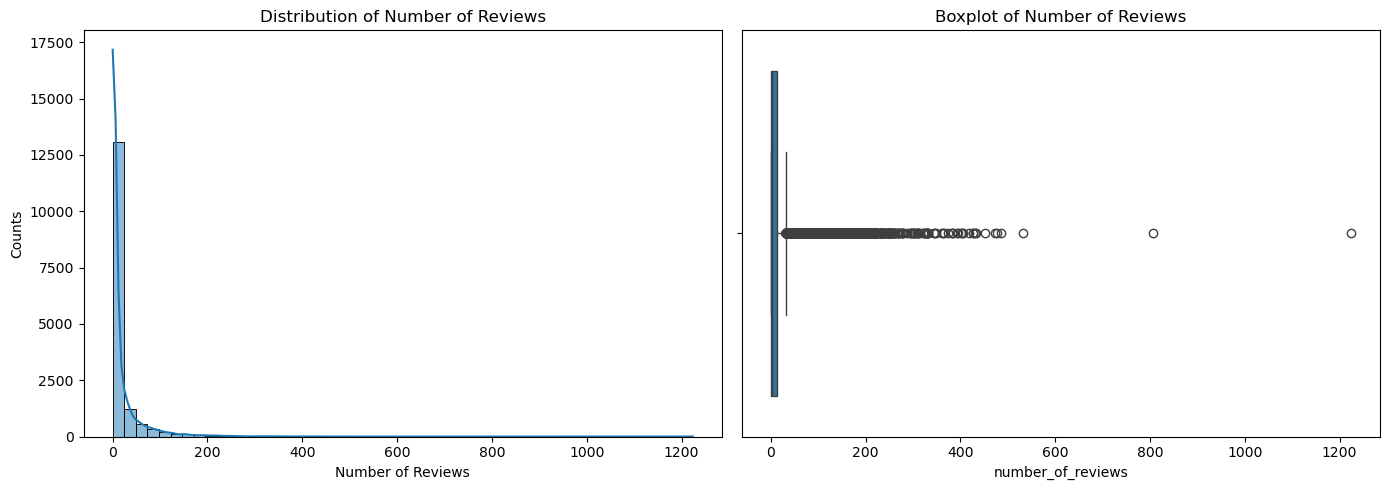

In [797]:
# checking the distribution of `number_of_reviews`
def histplot_review(ax):
    sns.histplot(
        airbnb['number_of_reviews'],
        bins=50,
        kde=True,
        ax=ax
    )
    ax.set_title('Distribution of Number of Reviews')
    ax.set_xlabel('Number of Reviews')
    ax.set_ylabel('Counts')

def boxplot_review(ax):
    sns.boxplot(
        x=airbnb['number_of_reviews'],
        ax=ax
    )
    ax.set_title('Boxplot of Number of Reviews')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
histplot_review(axes[0])
boxplot_review(axes[1])

plt.tight_layout()
plt.show()


In [798]:
Q1 = airbnb['number_of_reviews'].quantile(0.25)
Q2 = airbnb['number_of_reviews'].median()
Q3 = airbnb['number_of_reviews'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outlier_count = len(airbnb[airbnb['number_of_reviews'] > upper_bound])
mean =round(airbnb['number_of_reviews'].mean(),2)

print('\n--- DISTRIBUSI REVIEWS ---\n')
print(f'Q1 number_of_reviews : {Q1}')
print(f'Q2 number_of_reviews : {Q2}')
print(f'Q3 number_of_reviews : {Q3}')
print(f'Upperbound number_of_reviews : {upper_bound}')
print(f'Outlier Counts : {outlier_count}')
print(f'Mean number_of_counts: {mean}')


--- DISTRIBUSI REVIEWS ---

Q1 number_of_reviews : 0.0
Q2 number_of_reviews : 2.0
Q3 number_of_reviews : 13.0
Upperbound number_of_reviews : 32.5
Outlier Counts : 2240
Mean number_of_counts: 16.66


Untuk memastikan distribusi `number_of_reviews`, uji normalitas dengan shapiro wilk test akan dilakukan:

In [799]:
p_val=shapiro(airbnb['number_of_reviews'])[1]

if p_val <= 0.05:
    print(f"p-value = {p_val} ≤ 0.05, maka menurut uji Shapiro Wilk kolom number_of_reviews tidak terdistribusi normal")
else:
    print(f"p-value = {p_val} > 0.05, maka menurut uji Shapiro Wilk kolom number_of_reviews terdistribusi normal")


p-value = 7.383836886982803e-113 ≤ 0.05, maka menurut uji Shapiro Wilk kolom number_of_reviews tidak terdistribusi normal


Distribusi review sangat right skewed dengan mean: 16 jauh di atas median: 2. Selanjutnya, pengecekan proporsi antara listing tanpa review (`number_of_reviews` = 0) dan listing dengan review.

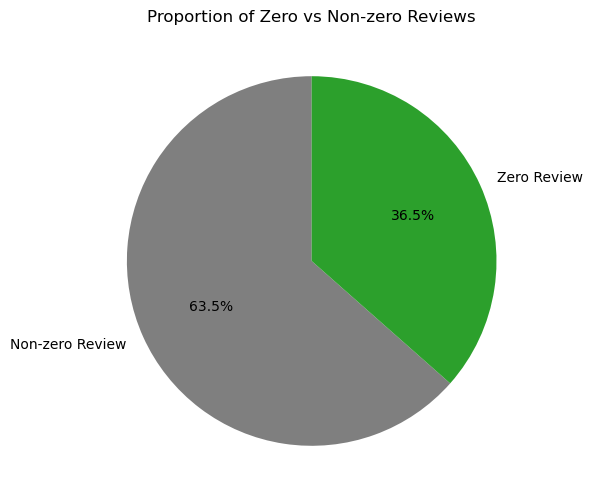

In [800]:
# checking zero proportion of `number_of_reviews`
review_prop = airbnb['number_of_reviews'].apply(
    lambda x: 'Zero Review' if x == 0 else 'Non-zero Review'
).value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    review_prop,
    labels=review_prop.index,
    autopct='%1.1f%%',
    startangle=90,
    colors = ['#7f7f7f', '#2ca02c']
)
plt.title('Proportion of Zero vs Non-zero Reviews')
plt.show()


Selanjutnya, trend review per tahun akan dicek. Namun, dengan kolom `number_of_reviews` yang 0 maka otomatis nilai tersebut tidak akan menambah jumlah review di tahun tersebut.

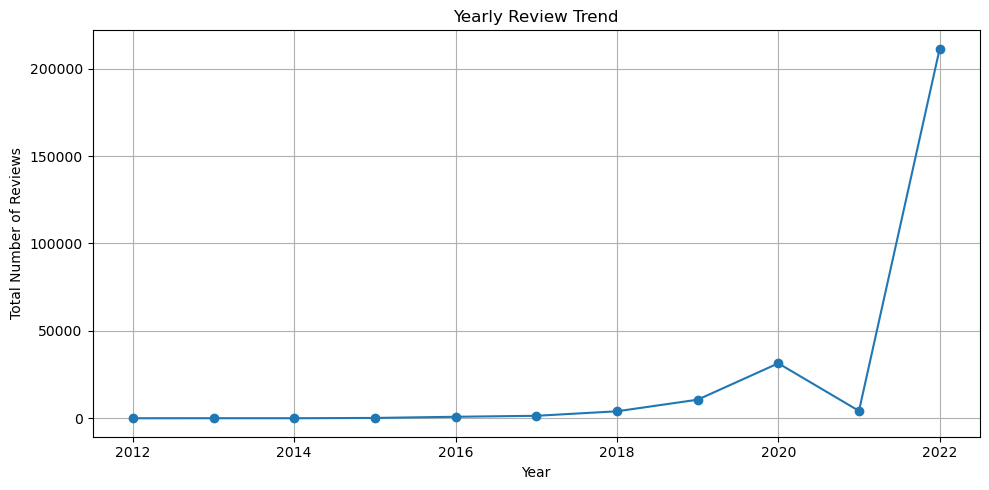

None

,review_year,total_reviews,active_listings,avg_reviews_per_listing
0,2012,4,1,4.000000
1,2013,30,7,4.285714
2,2014,16,9,1.777778
3,2015,182,50,3.640000
4,2016,852,149,5.718121
5,2017,1407,269,5.230483
6,2018,3978,484,8.219008
7,2019,10616,1012,10.490119
8,2020,31423,1248,25.178686
9,2021,4199,207,20.285024


In [801]:
# Buat tabel baru untuk cek tren review
review_trend = pd.DataFrame({
    'listing_id': airbnb.index if airbnb.index.name else range(len(airbnb)),
    'has_reviews': airbnb['number_of_reviews'] > 0,
    'total_reviews': airbnb['number_of_reviews'],
    'last_review_date': airbnb['last_review'],
})

# Tambahkan tahun review (hanya untuk yang punya review)
review_trend['review_year'] = np.where(
    review_trend['has_reviews'],
    review_trend['last_review_date'].dt.year,
    pd.NA
)

# Filter: hanya listing dengan review & tahun valid
review_trend_clean = review_trend[
    review_trend['review_year'].notna()
].copy()

review_trend_clean['review_year'] = review_trend_clean['review_year'].astype(int)

# Agregasi: total review per tahun
yearly_review_trend = (
    review_trend_clean
    .groupby('review_year', as_index=False)
    .agg(
        total_reviews=('total_reviews', 'sum'),
        active_listings=('listing_id', 'nunique')
    )
    .sort_values('review_year')
)

# Tambahkan rata-rata review per listing
yearly_review_trend['avg_reviews_per_listing'] = (
    yearly_review_trend['total_reviews']
    / yearly_review_trend['active_listings']
)

# Visualisasi: Line Plot Total Reviews per Year
def visualization():
    plt.figure(figsize=(10, 5))
    plt.plot(
        yearly_review_trend['review_year'],
        yearly_review_trend['total_reviews'],
        marker='o'
    )

    plt.title('Yearly Review Trend')
    plt.xlabel('Year')
    plt.ylabel('Total Number of Reviews')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

display(visualization(),yearly_review_trend)

### **Insights**
Lineplot menggambarkan jumlah review yang stagnan rendah dari tahun 2012 hingga mulai terjadi kenaikan di ttahun 2017 dan terus naik. Akan tetapi, terjadi penurunan yang cukup signifikan pada tahun 2020 ke 2021. Namun, setelah tahun 2021 hingga 2022 terjadi lonjakan jumlah review.

Trend jumlah review yang konstan meningkat ini, dapat dimanfaatkan oleh host ataupun host management team untuk menaikkan engagement listing melalui review listing oleh tamu.

#### 2. Reviews Distribution by `neighbourhood`

Pengecekan 10 wilayah dengan listing paling banyak serta distribusi jumlah review tiap wilayah:

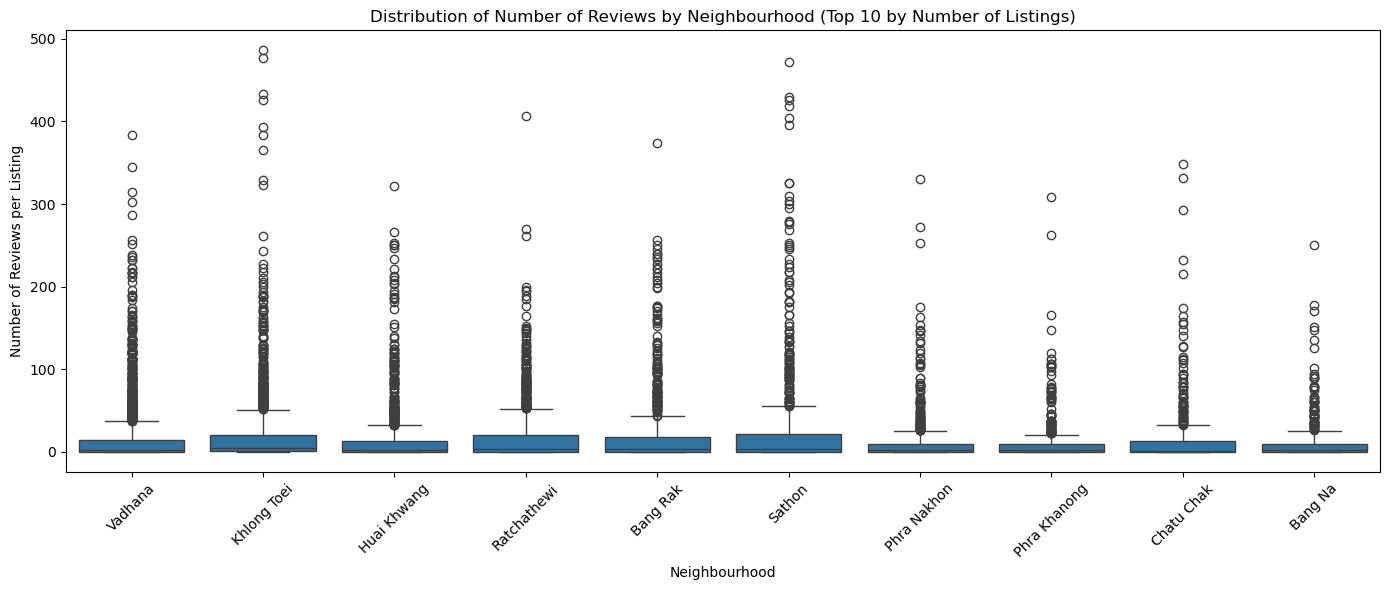

In [802]:
# Top 10 neighbourhood dengan jumlah listing terbanyak
top_neighbourhoods = (
    airbnb['neighbourhood']
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(14, 6))

airbnb_top = airbnb[airbnb['neighbourhood'].isin(top_neighbourhoods)]

sns.boxplot(
    data=airbnb_top,
    x='neighbourhood',
    y='number_of_reviews',  # distribusi number_of_review
    order=top_neighbourhoods  
)

plt.title('Distribution of Number of Reviews by Neighbourhood (Top 10 by Number of Listings)')
plt.xticks(rotation=45)
plt.ylabel('Number of Reviews per Listing')
plt.xlabel('Neighbourhood')

plt.tight_layout()
plt.show()



Pengecekan 10 wilayah yang paling banyak zero review:

In [803]:
# 1. Hitung jumlah listing dengan 0 reviews per neighbourhood
zero_reviews_by_neighbourhood = airbnb[airbnb['number_of_reviews'] == 0].groupby('neighbourhood').size()

# 2. Ambil top 10 neighbourhood dengan 0 reviews terbanyak
top_zero_reviews = zero_reviews_by_neighbourhood.sort_values(ascending=False).head(10)

print("Top 10 Neighbourhood dengan Paling Banyak 0 Reviews:")
for i, (neighbourhood, count) in enumerate(top_zero_reviews.items(), 1):
    print(f"{i}. {neighbourhood}: {count} listings tanpa review")

Top 10 Neighbourhood dengan Paling Banyak 0 Reviews:
1. Vadhana: 754 listings tanpa review
2. Khlong Toei: 477 listings tanpa review
3. Huai Khwang: 389 listings tanpa review
4. Ratchathewi: 342 listings tanpa review
5. Chatu Chak: 256 listings tanpa review
6. Bang Rak: 241 listings tanpa review
7. Phra Nakhon: 237 listings tanpa review
8. Sathon: 236 listings tanpa review
9. Phra Khanong: 214 listings tanpa review
10. Suanluang: 188 listings tanpa review


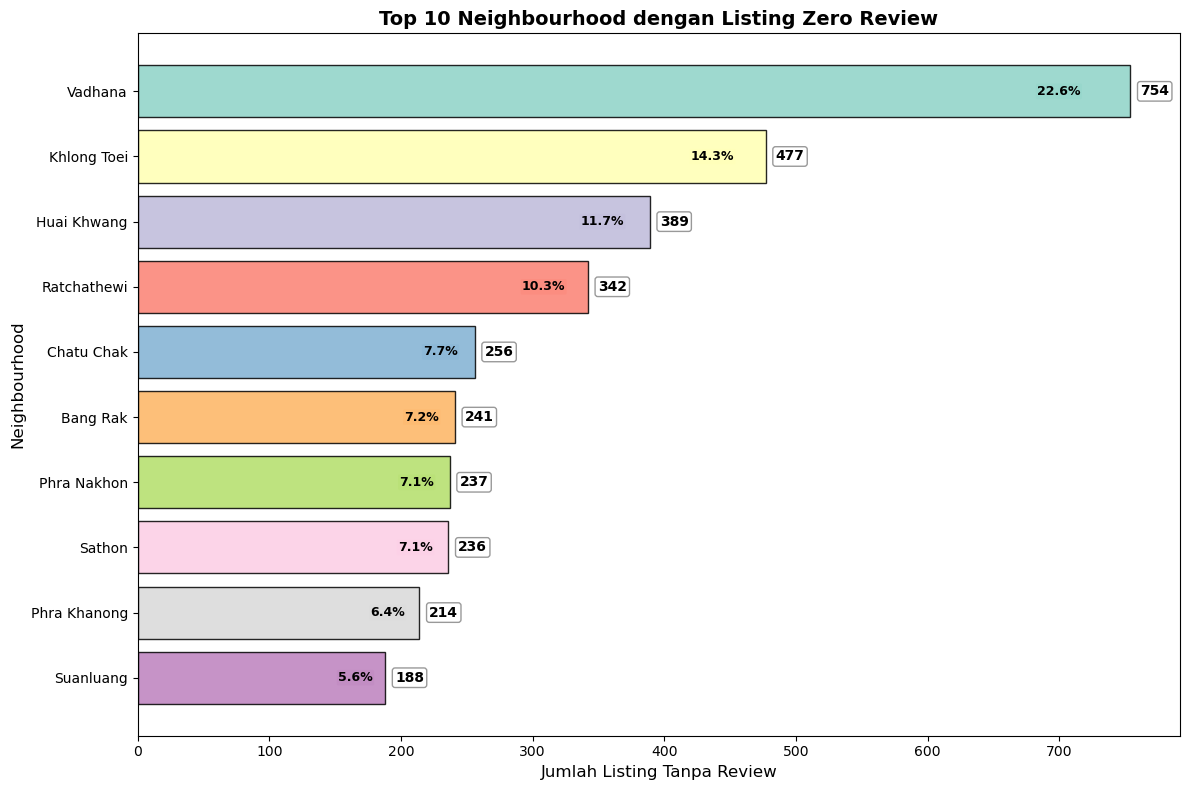

In [804]:
plt.figure(figsize=(12, 8))

# Hitung persentase
total = top_zero_reviews.values.sum()
percentages = (top_zero_reviews.values / total * 100)

# Buat warna berbeda untuk setiap wilayah
colors = plt.cm.Set3(np.arange(len(top_zero_reviews)))

# Buat bar plot
bars = plt.barh(top_zero_reviews.index, top_zero_reviews.values, 
                color=colors, alpha=0.85, edgecolor='black', linewidth=1)
plt.gca().invert_yaxis()
plt.title('Top 10 Neighbourhood dengan Listing Zero Review', 
          fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Listing Tanpa Review', fontsize=12)
plt.ylabel('Neighbourhood', fontsize=12)

max_value = max(top_zero_reviews.values)

# Set: tambahkan persentase (di dalam/di atas bar) dan quantity (di luar)
for bar, qty, pct, color in zip(bars, top_zero_reviews.values, percentages, colors):
    width = bar.get_width()
    
    if width > max_value * 0.05:
        brightness = np.mean(color[:3])
        text_color = 'white' if brightness < 0.6 else 'black'
        
        pct_x_pos = max(width * 0.95, 1)
        plt.text(pct_x_pos, 
                 bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}%', 
                 ha='right', va='center', fontsize=9, 
                 color=text_color, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor=color, alpha=0.3, edgecolor='none'))
    else:
        plt.text(width + max_value * 0.005,
                 bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}%', 
                 ha='left', va='center', fontsize=8, 
                 color='darkred', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.1', facecolor='yellow', alpha=0.2, edgecolor='none'))
    
    plt.text(width + max_value * 0.01,
             bar.get_y() + bar.get_height()/2, 
             f'{int(qty)}', 
             ha='left', va='center', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

Peta 10 `neighbourhood` dengan zero review paling banyak:

In [805]:
import folium

# Data wilayah (perkiraan koordinat pusat distrik Bangkok)
areas = [
    {"name": "Vadhana", "lat": 13.7367, "lon": 100.5765, "count": 754},
    {"name": "Khlong Toei", "lat": 13.7080, "lon": 100.5831, "count": 477},
    {"name": "Huai Khwang", "lat": 13.7760, "lon": 100.5790, "count": 389},
    {"name": "Ratchathewi", "lat": 13.7570, "lon": 100.5330, "count": 342},
    {"name": "Chatu Chak", "lat": 13.8285, "lon": 100.5560, "count": 256},
    {"name": "Bang Rak", "lat": 13.7270, "lon": 100.5240, "count": 241},
    {"name": "Phra Nakhon", "lat": 13.7640, "lon": 100.4990, "count": 237},
    {"name": "Sathon", "lat": 13.7190, "lon": 100.5260, "count": 236},
    {"name": "Phra Khanong", "lat": 13.7050, "lon": 100.6010, "count": 214},
    {"name": "Suanluang", "lat": 13.7290, "lon": 100.6480, "count": 188},
]

# Inisialisasi map (pusat Bangkok)
m = folium.Map(location=[13.7563, 100.5018], zoom_start=11)

# Tambahkan marker
for area in areas:
    folium.Marker(
        location=[area["lat"], area["lon"]],
        popup=f"""
        <b>{area['name']}</b><br>
        Listings tanpa review: {area['count']}
        """,
        tooltip=area["name"],
        icon=folium.Icon(icon="info-sign")
    ).add_to(m)

# Simpan ke file HTML
m.save("bangkok_listings_tanpa_review.html")
m


### **Insights**
Wilayah dengan zero review terkonsentrasi pada area pusat Bangkok, di mana area tersebut didominasi oleh kawasan komersial dan bisnis. Banyaknya properti sewa jangka pendek pada wilayah-wilayah tersebut juga dapat mendukung rendahnya jumlah review karena persaingan yang tinggi.

#### 3. Reviews Distribution by Room Type

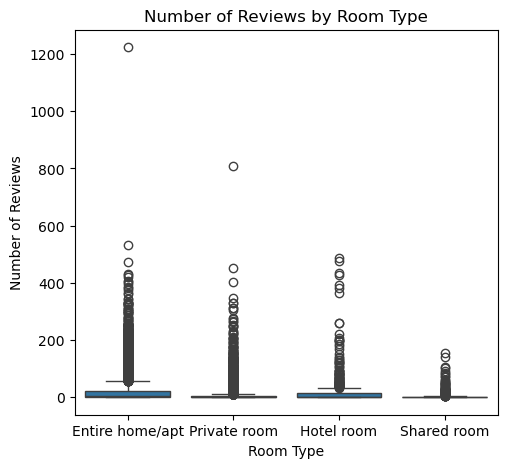

In [807]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=airbnb, x='room_type', y='number_of_reviews')
plt.title('Number of Reviews by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Reviews')

plt.show()

In [808]:
# Hitung jumlah listing dengan Zero review per tipe properti
zero_rev = airbnb[airbnb['number_of_reviews'] == 0]
count_zero_by_type = zero_rev['room_type'].value_counts()

# Hitung total listing per tipe properti
total_by_type = airbnb['room_type'].value_counts()

# Hitung persentase
percentage_zero = (count_zero_by_type / total_by_type * 100).round(2)

# Buat DataFrame untuk analisis
analysis_df = pd.DataFrame({
    'Total_Listings': total_by_type,
    'Zero_Reviews': count_zero_by_type,
    'Percentage_Zero': percentage_zero
}).fillna(0)

print("Listing dengan Zero Review per Tipe Properti:")
print("=" * 60)
print(analysis_df)
print("\n" + "=" * 60)

Listing dengan Zero Review per Tipe Properti:
                 Total_Listings  Zero_Reviews  Percentage_Zero
room_type                                                     
Entire home/apt            8912          2344            26.30
Hotel room                  648           198            30.56
Private room               5770          2929            50.76
Shared room                 523           318            60.80



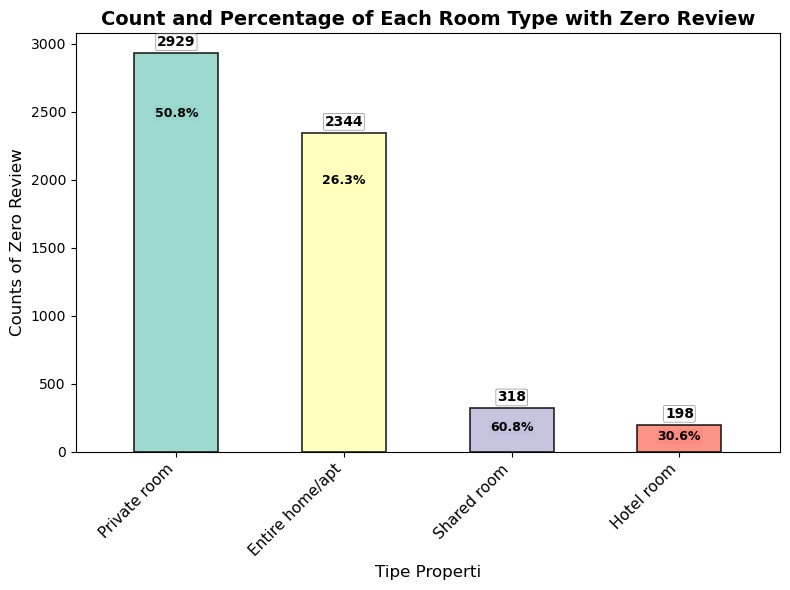

In [809]:
plt.figure(figsize=(8, 6))

# Urutkan dari besar ke kecil berdasarkan jumlah Zero_Reviews
analysis_df_sorted = analysis_df.sort_values('Zero_Reviews', ascending=False)

# Set warna berbeda untuk setiap tipe properti
colors = plt.cm.Set3(np.arange(len(analysis_df_sorted)))

# Set bar
bar_width = 0.5
x_positions = np.arange(len(analysis_df_sorted))

bars = plt.bar(x_positions, analysis_df_sorted['Zero_Reviews'].values, 
               color=colors, alpha=0.85, edgecolor='black', linewidth=1.2, 
               width=bar_width)

# Set x-ticks
plt.xticks(x_positions, analysis_df_sorted.index, rotation=45, ha='right', fontsize=11)

plt.title('Count and Percentage of Each Room Type with Zero Review', 
          fontsize=14, fontweight='bold')
plt.xlabel('Tipe Properti', fontsize=12)
plt.ylabel('Counts of Zero Review', fontsize=12)

# Set xlim
plt.xlim(-0.6, len(analysis_df_sorted) - 0.4)

# Set nilai maksimum untuk referensi
max_value = max(analysis_df_sorted['Zero_Reviews'].values)

# Set label:
for i, (bar, qty, pct, color) in enumerate(zip(bars, 
                                              analysis_df_sorted['Zero_Reviews'].values, 
                                              analysis_df_sorted['Percentage_Zero'].values, 
                                              colors)):
    height = bar.get_height()
    x_pos = bar.get_x() + bar.get_width()/2

    plt.text(x_pos, height + max_value * 0.01,
             f'{int(qty)}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.9, 
                      edgecolor='gray', linewidth=0.5))
    
    brightness = np.mean(color[:3])
    text_color = 'white' if brightness < 0.6 else 'black'

    height_ratio = height / max_value if max_value > 0 else 0


    if height_ratio > 0.5:
        pct_y_pos = height * 0.85
    elif height_ratio > 0.3:
        pct_y_pos = height * 0.75
    elif height_ratio > 0.15:
        pct_y_pos = height * 0.65
    elif height_ratio > 0.05:
        pct_y_pos = height * 0.55
    else:
        pct_y_pos = height * 0.5
    

    if height > max_value * 0.04:
        plt.text(x_pos, pct_y_pos, 
                 f'{pct:.1f}%', 
                 ha='center', va='center', fontsize=9, 
                 color=text_color, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.08', facecolor=color, 
                          alpha=0.4, edgecolor='none'))
    else:
        plt.text(x_pos, height + max_value * 0.01, 
                 f'{pct:.1f}%', 
                 ha='center', va='bottom', fontsize=8, 
                 color='darkred', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.05', facecolor='yellow', 
                          alpha=0.2, edgecolor='none'))

plt.tight_layout()
plt.show()

### **Insights**
Private room merupakan tipe properti yang paling banyak memiliki zero review dibandingkan tipe properti lainnya. Ini artinya, tamu yang menginap di kamar pribadi atau bersama lebih jarang meninggalkan review. Sedangkan tamu yang menyewa seluruh properti (Entire home/apt) cenderung lebih terdorong untuk meninggalkan review.

#### 4. Price Distribution


DESKRIPSI PRICE:
count    1.585300e+04
mean     3.217907e+03
std      2.497290e+04
min      2.780000e+02
25%      9.000000e+02
50%      1.429000e+03
75%      2.429000e+03
max      1.100000e+06
Name: price, dtype: float64


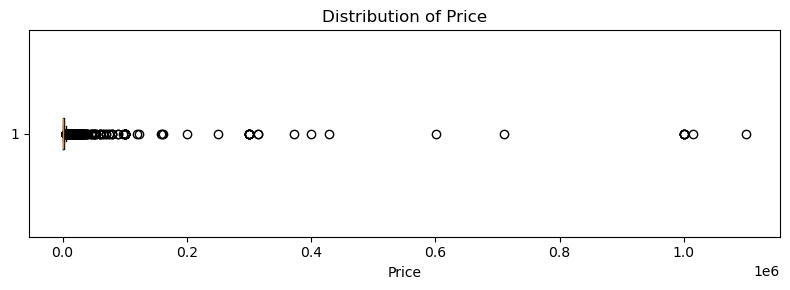

In [810]:
# 1. Deskriptif dasar
print("DESKRIPSI PRICE:")
print(airbnb['price'].describe())

# 3. Boxplot price (cek outlier)
plt.figure(figsize=(8,3))
plt.boxplot(airbnb['price'], vert=False)
plt.xlabel('Price')
plt.title('Distribution of Price')
plt.tight_layout()
plt.show()


<Axes: xlabel='number_of_reviews', ylabel='price'>

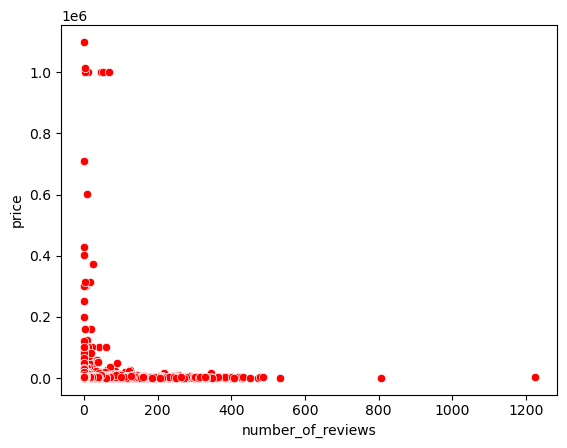

In [811]:
sns.scatterplot(data=airbnb, x='number_of_reviews', y='price', color='red')

### **Insights**
Boxplot di atas menunjukkan ada banyak sekali outlier pada distribusi `price`. Untuk mengecek korelasi antara harga dengan jumlah review, perlu dilakukan uji korelasi Spearman.

In [812]:
corr_price_rev = airbnb[['price', 'number_of_reviews']].corr(method='spearman')
rho = corr_price_rev.loc['price', 'number_of_reviews']

# Klasifikasi kekuatan korelasi
abs_rho = abs(rho)

if abs_rho < 0.10:
    strength = "sangat lemah"
elif abs_rho < 0.30:
    strength = "lemah"
elif abs_rho < 0.50:
    strength = "sedang"
else:
    strength = "kuat"

direction = "negatif (harga naik → jumlah review cenderung turun)" if rho < 0 else "positif" if rho > 0 else "tidak ada"

print(f"Spearman correlation (ρ): {round(rho,3)}")
print(f"Arah hubungan: {direction}")
print(f"Kekuatan hubungan: {strength}")


Spearman correlation (ρ): -0.021
Arah hubungan: negatif (harga naik → jumlah review cenderung turun)
Kekuatan hubungan: sangat lemah


### **Insights**
Berdasarkan hasil uji korelasi Spearman, jumlah review dan harga berkorelasi negatif (saat harga naik, jumlah review cenderung turun) dan sangat lemah. Apabila kita hitung korelasi antara jumlah review dengan harga untuk setiap tipe properti:

In [813]:
# Mendapatkan daftar Room Type unik dari DataFrame
unique_room_types = airbnb['room_type'].unique()

# Loop untuk menghitung korelasi antara Number of Reviews dan Price untuk setiap Room Type
for room_type in unique_room_types:
    # Filter DataFrame berdasarkan Room Type
    filtered_data = airbnb[airbnb['room_type'] == room_type]
    
    # Menghitung korelasi antara Number of Reviews dan Price untuk Room Type yang dipilih
    correlation = filtered_data['number_of_reviews'].corr(filtered_data['price'])
    
    print(f"Tipe properti: {room_type}")
    print(f"Jumlah data: {len(filtered_data)}")
    print(f"Nilai korelasi: {round(correlation,4)}")
    
    # Menentukan kekuatan dan arah korelasi
    if abs(correlation) >= 0.7:
        strength = "Kuat"
    elif abs(correlation) >= 0.3:
        strength = "Sedang"
    else:
        strength = "Lemah"
    
    if correlation > 0:
        direction = "Positif"
        interpretation = "Semakin banyak review, harga cenderung lebih tinggi"
    elif correlation < 0:
        direction = "Negatif"
        interpretation = "Semakin banyak review, harga cenderung lebih rendah"
    else:
        direction = "Tidak ada"
        interpretation = "Tidak ada hubungan linear"
    
    print(f"Kekuatan korelasi: {strength}")
    print(f"Arah korelasi: {direction}")
    print(f"Interpretasi: {interpretation}")
    print("-" * 50)

Tipe properti: Entire home/apt
Jumlah data: 8912
Nilai korelasi: -0.0031
Kekuatan korelasi: Lemah
Arah korelasi: Negatif
Interpretasi: Semakin banyak review, harga cenderung lebih rendah
--------------------------------------------------
Tipe properti: Private room
Jumlah data: 5770
Nilai korelasi: -0.018
Kekuatan korelasi: Lemah
Arah korelasi: Negatif
Interpretasi: Semakin banyak review, harga cenderung lebih rendah
--------------------------------------------------
Tipe properti: Hotel room
Jumlah data: 648
Nilai korelasi: -0.0266
Kekuatan korelasi: Lemah
Arah korelasi: Negatif
Interpretasi: Semakin banyak review, harga cenderung lebih rendah
--------------------------------------------------
Tipe properti: Shared room
Jumlah data: 523
Nilai korelasi: -0.0553
Kekuatan korelasi: Lemah
Arah korelasi: Negatif
Interpretasi: Semakin banyak review, harga cenderung lebih rendah
--------------------------------------------------


## 5. Data Analysing

#### 1. Differences Between Neighbourhood (Kruskal-Wallis Test)

In [814]:
# UJI UNTUK NEIGHBOURHOOD
print("\n" + "-"*45)
print("UJI KRUSKAL-WALLIS: REVIEW vs NEIGHBOURHOOD")
print("-"*45)

print("HIPOTESIS:")
print("H₀: Median review sama di semua neighbourhood.")
print("H₁: Ada perbedaan median review di minimal dua neighbourhood.")

# Eksekusi test
min_samples = 5
valid_locations = airbnb['neighbourhood'].value_counts()[airbnb['neighbourhood'].value_counts() >= min_samples].index

if len(valid_locations) >= 3:
    groups = [airbnb[airbnb['neighbourhood'] == loc]['number_of_reviews'] for loc in valid_locations]
    h_stat, p_value = stats.kruskal(*groups)
    
    print(f"\nHASIL UJI:")
    print(f"α = 0.05")
    print(f"Statistik H = {h_stat:.2f}")
    print(f"P-value = {p_value:.4f}")
    
    print(f"\nKEPUTUSAN:")
    if p_value < 0.05:
        print(f"→ Karena p-value ({p_value:.4f}) < α (0.05)")
        print(f"→ TOLAK H₀")
        print(f"→ TERIMA H₁: Ada perbedaan signifikan review antar neighbourhood")
    else:
        print(f"→ Karena p-value ({p_value:.4f}) ≥ α (0.05)")
        print(f"→ GAGAL TOLAK H₀")
        print(f"→ Tidak cukup bukti untuk mengatakan ada perbedaan review antar neighbourhood")
else:
    print("Tidak cukup kelompok untuk uji Kruskal-Wallis")


---------------------------------------------
UJI KRUSKAL-WALLIS: REVIEW vs NEIGHBOURHOOD
---------------------------------------------
HIPOTESIS:
H₀: Median review sama di semua neighbourhood.
H₁: Ada perbedaan median review di minimal dua neighbourhood.

HASIL UJI:
α = 0.05
Statistik H = 926.57
P-value = 0.0000

KEPUTUSAN:
→ Karena p-value (0.0000) < α (0.05)
→ TOLAK H₀
→ TERIMA H₁: Ada perbedaan signifikan review antar neighbourhood


#### 2. Differences Between Room Type (Kruskal-Wallis)

In [815]:
print("-"*32)
print("UJI ROOM TYPE - KRUSKAL WALLIS")
print("-"*32)

# 1. Tipe properti
print("Tipe Properti yang ada:")
room_types = airbnb['room_type'].unique()
for rt in room_types:
    count = len(airbnb[airbnb['room_type'] == rt])
    print(f"- {rt}: {count} listing")

# 2. Hipotesis
print("\nHIPOTESIS:")
print("H₀: Median review sama semua tipe")
print("H₁: Ada beda median review minimal 2 tipe")

# 3. Kruskal-Wallis test
groups = []
for rt in room_types:
    data = airbnb[airbnb['room_type'] == rt]['number_of_reviews']
    groups.append(data)

h_stat, p_value = stats.kruskal(*groups)

# 4. Hasil
print(f"\nHASIL Kruskal-Wallis:")
print(f"P-value = {p_value:.4f}")
print(f"α = 0.05")

# 5. KEPUTUSAN STATISTIK
print(f"\nKEPUTUSAN:")

if p_value < 0.05:
    print(f"→ Karena p-value ({p_value:.4f}) < α (0.05)")
    print(f"→ TOLAK H₀")
    print(f"→ TERIMA H₁: Ada perbedaan signifikan review antar tipe properti")
    
    # Ranking
    print(f"\nRanking (berdasarkan median):")
    medians = airbnb.groupby('room_type')['number_of_reviews'].median().sort_values(ascending=False)
    
    for i, (rt, med) in enumerate(medians.items(), 1):
        print(f"{i}. {rt}: {med:.0f} review")
    
    # Best vs worst
    best = medians.index[0]
    worst = medians.index[-1]
    ratio = medians.iloc[0] / medians.iloc[-1]

else:
    print(f"→ Karena p-value ({p_value:.4f}) ≥ α (0.05)")
    print(f"→ GAGAL TOLAK H₀")
    print(f"→ Tidak cukup bukti untuk mengatakan ada perbedaan review antar tipe properti")

--------------------------------
UJI ROOM TYPE - KRUSKAL WALLIS
--------------------------------
Tipe Properti yang ada:
- Entire home/apt: 8912 listing
- Private room: 5770 listing
- Hotel room: 648 listing
- Shared room: 523 listing

HIPOTESIS:
H₀: Median review sama semua tipe
H₁: Ada beda median review minimal 2 tipe

HASIL Kruskal-Wallis:
P-value = 0.0000
α = 0.05

KEPUTUSAN:
→ Karena p-value (0.0000) < α (0.05)
→ TOLAK H₀
→ TERIMA H₁: Ada perbedaan signifikan review antar tipe properti

Ranking (berdasarkan median):
1. Entire home/apt: 5 review
2. Hotel room: 2 review
3. Private room: 0 review
4. Shared room: 0 review


In [ ]:
# airbnb.to_csv('airbnb_to_analyzed.csv',index=0)

## Conclusion
Berdasarkan berbagai analisis yang telah dilakukan terhadap faktor-faktor yang memengaruhi kesenjangan aktivitas review pada listing Airbnb di Bangkok, beberapa kesimpulan dapat kita tarik: 

1. Secara keseluruhan, distribusi jumlah review listing tahun 2012 sampai 2022 tidak merata. Mayoritas listing memiliki jumlah review yang rendah atau bahkan nol. Proporsi review 0 cukup signifikan dari total review listing pada dataset. 
2. Trend jumlah review tiap tahunnya relatif stagnan dengan jumlah review yang rendah. Namun, mulai mengalami kenaikan di tahun 2018 dan turun drastis di tahun 2020 hingga 2021. Jumlah review selanjutnya mengalami lonjakan setelah tahun 2021.
3. Secara keseluruhan, distribusi review 0 cenderung terkonsentrasi pada tipe properti Private Room dan wilayah-wilayah seperti Vadhana, Khlong Toei, dan Huai Khwang.
4. Berdasarkan beberapa uji yang telah dilakukan, terdapat perbedaan signifikan jumlah review pada tipe properti dan wilayah tertentu. Hal ini menunjukkan tipe properti dan wilayah memiliki pengaruh terhadap jumlah review listing.
5. Sementara itu, uji korelasi antara harga dengan jumlah review menunjukkan korelasi negatif (harga naik → jumlah review cenderung turun) meskipun sangat lemah.


Analisis yang telah dilakukan terbatas pada dataset yang digunakan. Dataset mencakup data historis airbnb listings bangkok tahun 2012 hingga 2022. Variabel dalam analisis terbatas pada variable di dataset, tidak termasuk faktor kualitas properti seperti deskripsi, rating, dan host performance. Analisis juga tidak mencakup analisis sentimen tamu, hanya terbatas pada kuantitas review dan bukan kualitas review.

## Recommendation
Berikut beberapa strategi untuk meningkatkan engagement review listing:

1. Mempertimbangkan kolaborasi dengan afiliator/influencer untuk mempromosikan properti lebih luas sekaligus adakan program promo/diskon bagi tamu yang meninggalkan review. Berikan bonus bila review bagus.
2. Bersamaan dengan meningkatkan kualitas properti setiap listing serta layanan host.
3. Mempertimbangkan program loyalitas atau insentif bagi tamu yang memberikan review.
3. Untuk lokasi dengan jumlah review rendah, lakukan analisis lebih mendalam terkait segmen tamu kemudian rumuskan strategi peningkatan engagement yang relevan.
4. Tim Host Management dapat menerapkan program intervensi ini kepada host listing dengan aktivitas review rendah.
5. Membuat dashboard insights untuk host tentang performa relatif. 

---